# *Salaries of San Francisco Employees* 

- **Domain:** Finance Analytics  
- **Project Type:** Exploratory Data Analysis (EDA)  
- **Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, ML
- **Level:** Advanced

## **Introduction**
This project focuses on analyzing the salary structure of San Francisco employees. The dataset includes information about employee roles, base pay, overtime pay, benefits, and total compensation. The goal of this analysis is to understand salary patterns, identify trends, and gain insights into employee compensation across different job roles and years.

## **Objectives**
- Analyze salary distribution of employees  
- Compare base pay, overtime pay, and total compensation  
- Identify high-paying job roles  
- Understand trends in employee salaries

## **Dataset Description**

The dataset contains salary information of employees working in San Francisco.  
It provides detailed information about employee compensation, including base pay, overtime pay, benefits, and total salary.

### Key Columns

- **Id** – Unique identifier for each employee record  
- **EmployeeName** – Name of the employee  
- **JobTitle** – Job role/designation of the employee  
- **BasePay** – Base salary paid to the employee  
- **OvertimePay** – Additional pay for overtime work  
- **OtherPay** – Other types of compensation  
- **Benefits** – Benefits received by the employee  
- **TotalPay** – Sum of base pay, overtime pay, and other pay  
- **TotalPayBenefits** – Total compensation including benefits  
- **Year** – Year of the salary record  

The dataset is used to perform data cleaning, exploratory data analysis, and to understand salary patterns across different job roles and years.


# Step 1: Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import re
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv(r"C:\Users\Sumathi\Downloads\Total.csv", index_col=False)

In [3]:
# Display all columns,rows and removes floating values have more than 2 values after decimal like 10.12345
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
#Showing 1st five Rows

data.head()

,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,Not Provided,567595.43,567595.43,2011
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,Not Provided,538909.28,538909.28,2011
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,Not Provided,335279.91,335279.91,2011
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,Not Provided,332343.61,332343.61,2011
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,Not Provided,326373.19,326373.19,2011


# Step 2: Data Overview and Understanding
In this step, the dataset is explored to understand its structure, data types, and basic statistics.
This helps identify missing values, incorrect data types, and gives an overall idea of the dataset before cleaning.

In [5]:
#displays the shape of the data set

data.shape

(312882, 9)

In [6]:
# Check basic information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312882 entries, 0 to 312881
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   EmployeeName      312882 non-null  object 
 1   JobTitle          312882 non-null  object 
 2   BasePay           312882 non-null  object 
 3   OvertimePay       312882 non-null  object 
 4   OtherPay          312882 non-null  object 
 5   Benefits          312882 non-null  object 
 6   TotalPay          312882 non-null  float64
 7   TotalPayBenefits  312882 non-null  float64
 8   Year              312882 non-null  int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 21.5+ MB


In [7]:
# statistical summary of numerical columns

data.describe()

,TotalPay,TotalPayBenefits,Year
count,312882.00,312882.00,312882.00
mean,78802.65,100928.34,2014.63
std,53230.76,66485.19,2.29
min,-618.13,-3628.78,2011.00
25%,38803.00,48955.07,2013.00
50%,74908.79,100011.29,2015.00
75%,111386.90,142376.30,2017.00
max,592394.34,712802.36,2018.00


In [8]:
# column names

data.columns

Index(['EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year'],
      dtype='object')

# Step 3: Data Cleaning

In this step, the dataset is cleaned by handling missing values and fixing incorrect data types. Cleaning the data is important to ensure accurate analysis and meaningful insights.

In [9]:
#removes extra spaces or symbols on coloumn headings

[re.sub(r'[\s/]+', '_', x.strip()) for x in data.columns]

['EmployeeName',
 'JobTitle',
 'BasePay',
 'OvertimePay',
 'OtherPay',
 'Benefits',
 'TotalPay',
 'TotalPayBenefits',
 'Year']

In [10]:
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
dtype: int64


In [11]:
# Removing duplicate rows

data.drop_duplicates(inplace=True)

In [12]:
#data types of columns 

data.dtypes

EmployeeName         object
JobTitle             object
BasePay              object
OvertimePay          object
OtherPay             object
Benefits             object
TotalPay            float64
TotalPayBenefits    float64
Year                  int64
dtype: object

In [13]:
# Converting salary columns into numeric 

salary_cols = ["BasePay", "OvertimePay", "OtherPay", "Benefits", "TotalPay", "TotalPayBenefits"]

for col in salary_cols:
    data[col] = pd.to_numeric(data[col], errors= "coerce")

In [14]:
# data types of columns after converting 

data.dtypes

EmployeeName         object
JobTitle             object
BasePay             float64
OvertimePay         float64
OtherPay            float64
Benefits            float64
TotalPay            float64
TotalPayBenefits    float64
Year                  int64
dtype: object

# Final Cleaned Data

In [15]:
data.head()

,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011


In [16]:
data.tail()

,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year
312877,Daniel W Plautz,Public Service Trainee,0.00,0.00,0.00,0.00,0.00,0.00,2018
312878,David J Thompson,Deputy Sheriff,0.00,0.00,0.00,0.00,0.00,0.00,2018
312879,Keiko Weng Yee Lau,Public Service Trainee,0.00,0.00,0.00,0.00,0.00,0.00,2018
312880,David Wong,Deputy Sheriff,0.00,0.00,0.00,0.00,0.00,0.00,2018
312881,Debora E Howard,Recreation Leader,0.00,0.00,0.00,0.00,0.00,0.00,2018


# Data Profiling using YdataProfiling

YData Profiling is used to generate an automated and detailed report of the dataset. It helps to quickly understand data types, missing values, distributions, correlations, and potential data quality issues.

In [17]:
from ydata_profiling import ProfileReport

In [18]:
profile = ProfileReport(data, title="San Francisco Employee Salaries Profiling Report", explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:09<00:00,  1.05s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Step 4: Exploratary Data Anaalysis
### EDA 1. Distribution of Total Pay Benefits

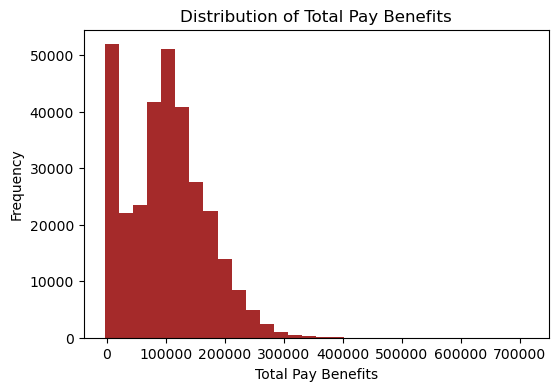

In [19]:
# 1. Distribution of Total Pay Benefits

plt.figure(figsize=(6,4))
plt.hist(data['TotalPayBenefits'], bins=30, color="brown")
color="purple"
plt.title("Distribution of Total Pay Benefits")
plt.xlabel("Total Pay Benefits")
plt.ylabel("Frequency")

# Save the figure
plt.savefig("TotalPayBenefits_Distribution.png")

plt.show()


**Key Insight:**

The distribution of total pay benefits is right-skewed, showing that most employees earn low to mid-level salaries. Only a small number of employees receive very high compensation, creating a long tail in the distribution.

### EDA 2. Salary Trend Over the Years

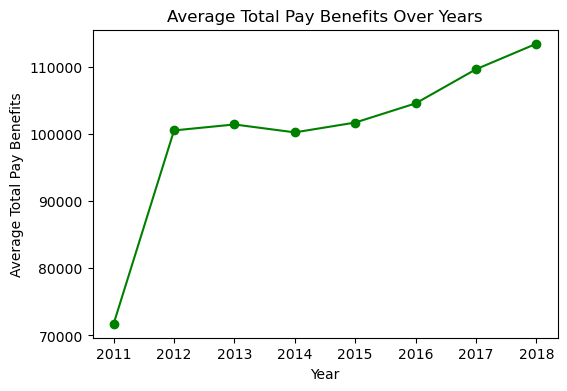

In [20]:
yearly_avg = data.groupby('Year')['TotalPayBenefits'].mean()

# Plot

plt.figure(figsize=(6,4))
plt.plot(yearly_avg.index, yearly_avg.values,color="green", marker='o')
plt.title("Average Total Pay Benefits Over Years")
plt.xlabel("Year")
plt.ylabel("Average Total Pay Benefits")
plt.savefig("Salary Trend Over the Years", dpi=300, bbox_inches='tight')
plt.show()

**Key Insights:**

Average total pay benefits show an overall increasing trend over the years. Despite minor fluctuations, employee compensation has steadily grown over time.

### EDA 3. Average Total Pay Over the Years

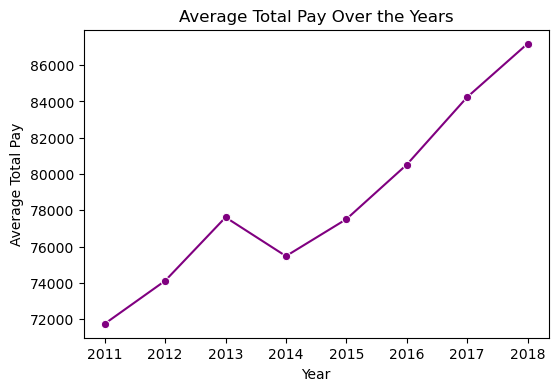

In [21]:
pay_over_years = data.groupby('Year')['TotalPay'].mean()

# Plot
plt.figure(figsize=(6,4))
sns.lineplot(x=pay_over_years.index, y=pay_over_years.values, marker="o", color="purple")

plt.title("Average Total Pay Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Total Pay")
plt.savefig("Average Total Pay Over the Years")
plt.show()

**Key Insights:**

The average total pay demonstrates gradual growth across years with a slight dip in the middle period. Overall, the trend indicates consistent salary increases.


### EDA 4. Top 10 Job Titles with Highest Average Salary

In [22]:
# Which job titles have the highest average salary?

# Group by JobTitle and calculate average TotalPay
job_salary = data.groupby('JobTitle')['TotalPay'].mean()

# Sort in descending order and take top 10
top_jobs = job_salary.sort_values(ascending=False).head(10)

print(top_jobs)


JobTitle
Chief Investment Officer                         496183.26
GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY   399211.28
Physician Administrator, DPH                     371433.09
Managing Director                                360485.33
Chief, Fire Department                           334602.16
Assistant Chief of Police                        315458.16
Gen Mgr, Public Trnsp Dept                       311300.66
DEPUTY DIRECTOR OF INVESTMENTS                   307899.46
CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)           302377.73
Administrator, DPH                               300149.34
Name: TotalPay, dtype: float64


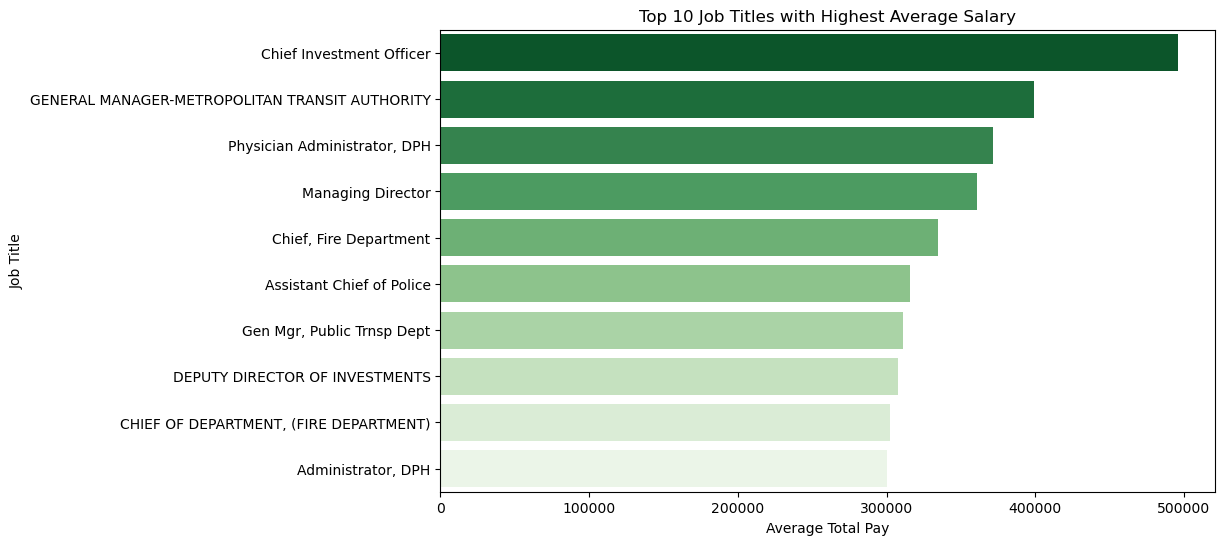

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index,
    palette="Greens_r"
)

plt.title("Top 10 Job Titles with Highest Average Salary")
plt.xlabel("Average Total Pay")
plt.ylabel("Job Title")

plt.savefig("Highest_Avg_Salary_JobTitles.png", dpi=300, bbox_inches='tight')
plt.show()


**Key Insights:**

The chart shows that executive and senior leadership roles receive the highest average salaries. Higher responsibility and managerial positions are strongly associated with higher compensation.

## EDA 5. Base Pay vs Total Pay Relationship

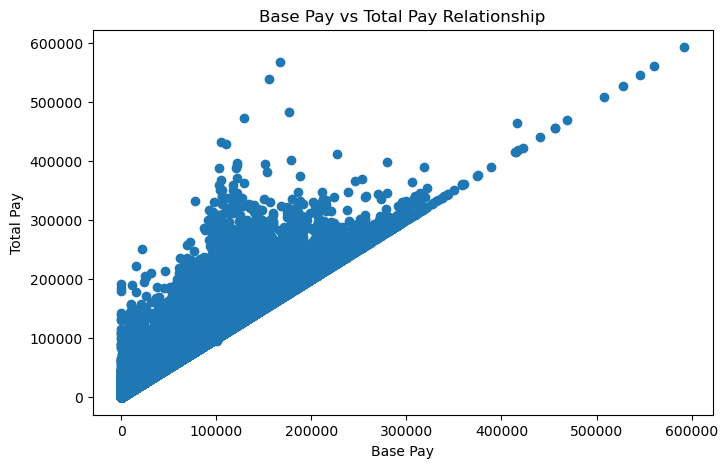

In [24]:
# Base Pay vs Total Pay Relationship
plt.figure(figsize=(8,5))

plt.scatter(data['BasePay'], data['TotalPay'])

plt.title("Base Pay vs Total Pay Relationship")
plt.xlabel("Base Pay")
plt.ylabel("Total Pay")

plt.savefig("BasePay_vs_TotalPay.png", dpi=300, bbox_inches='tight')
plt.show()


**Key Insights:**

The scatter plot shows a strong positive linear relationship between Base Pay and Total Pay. This indicates that Base Pay is the primary contributor to Total Pay. Most employees follow a consistent pay structure, with only a few outliers receiving significantly higher total pay due to overtime or additional benefits.

### EDA 6. Which jobs have highest overtime pay

In [25]:

# Group by JobTitle and calculate average OvertimePay
job_overtime = data.groupby('JobTitle')['OvertimePay'].mean()

# Sort in descending order and take top 10
top_overtime_jobs = job_overtime.sort_values(ascending=False).head(10)

print(top_overtime_jobs)


JobTitle
WIRE ROPE CABLE MAINTENANCE SUPERVISOR    66164.73
Mech Shop & Equip Supt                    64842.58
Transit Power Line Sprv1                  64661.96
Trnst Power Line Wrk Sprv 2               58707.26
Wire Rope Cable Maint Sprv                56663.96
Transportation Operations Spec            53130.14
Transit Power Line Worker                 50463.47
Track Maint Wrk Sprv 1                    49551.38
ASSISTANT INSPECTOR (POLICE DEPARTMENT)   45679.84
Auto Body & Fender Wrk Sprv 1             45308.24
Name: OvertimePay, dtype: float64


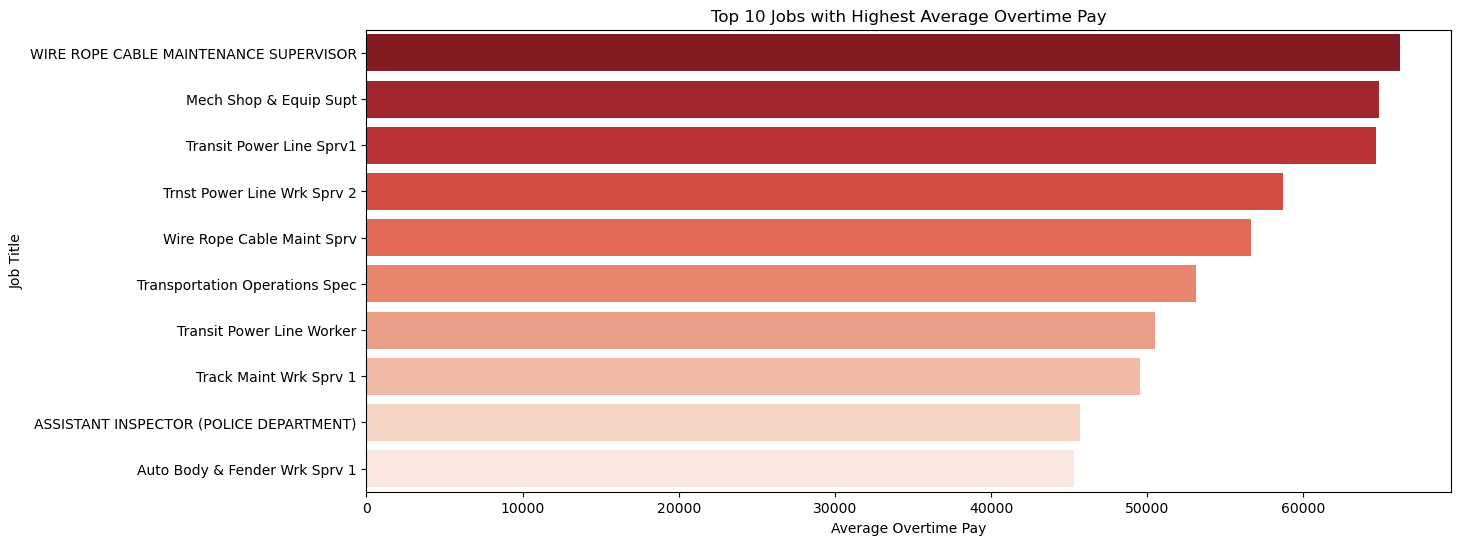

In [43]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=top_overtime_jobs.values,
    y=top_overtime_jobs.index,
    palette="Reds_r"
)

plt.title("Top 10 Jobs with Highest Average Overtime Pay")
plt.xlabel("Average Overtime Pay")
plt.ylabel("Job Title")

plt.savefig("Highest_OvertimePay_Jobs.png", dpi=300, bbox_inches='tight')
plt.show()


**Key Insights:**

The analysis shows that overtime pay is highly concentrated in a few specific job titles. Certain roles consistently earn much higher overtime compared to others, indicating that overtime requirements are job-dependent rather than uniform across the organization. This insight can help management monitor overtime costs and plan better resource allocation.

### EDA 7: Top 10 employees who get highest benefits

In [27]:
import pandas as pd

# Sort employees by Benefits in descending order
top_benefits = data[['EmployeeName', 'JobTitle', 'Benefits']] \
                .sort_values(by='Benefits', ascending=False) \
                .head(10)

print(top_benefits)



                 EmployeeName                      JobTitle  Benefits
148650   William J Coaker Jr.      Chief Investment Officer 125891.73
229007   William J Coaker Jr.      Chief Investment Officer 120885.28
270573          Paulo Morgado              Police Officer 3 120408.02
270574   William J Coaker Jr.      Chief Investment Officer 119876.54
188037   William J Coaker Jr.      Chief Investment Officer 114502.68
229008         David E Francl             Managing Director 109857.43
229013      Andrew J Sisneros              Transit Operator 105695.90
229011        Susan P Ehrlich  Physician Administrator, DPH 102849.30
229012  Ellen Munson Brownell             Managing Director 102069.57
110533   William J Coaker Jr.      Chief Investment Officer  96570.66


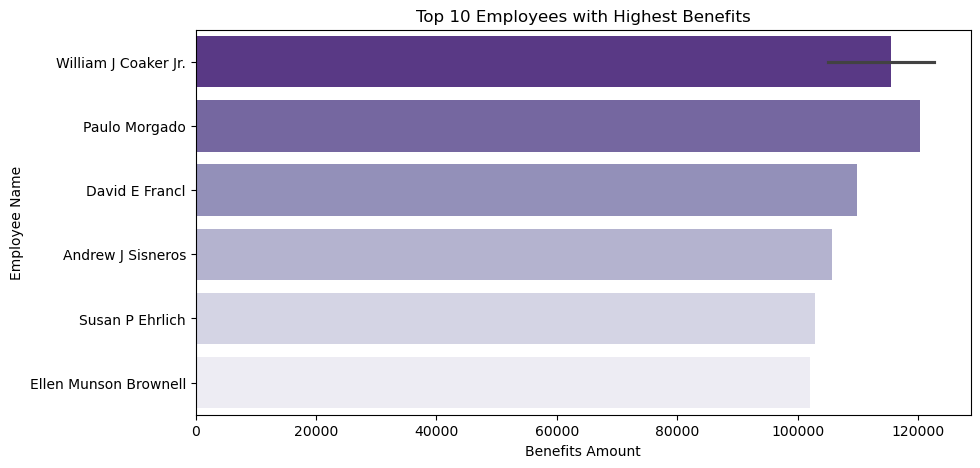

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_benefits['Benefits'],
    y=top_benefits['EmployeeName'],
    palette="Purples_r"
)

plt.title("Top 10 Employees with Highest Benefits")
plt.xlabel("Benefits Amount")
plt.ylabel("Employee Name")

plt.savefig("Highest_Benefits_Employees.png", dpi=300, bbox_inches='tight')
plt.show()


**Key Insights:**

The chart reveals that average benefits vary greatly across job titles, with a few roles receiving significantly higher benefits than others. This indicates that benefit allocation is closely tied to job position and seniority. The organization follows a structured benefits system where higher-level or specialized roles are rewarded with greater benefit packages.

### EDA 8: Employees Receiving Overtime Pay

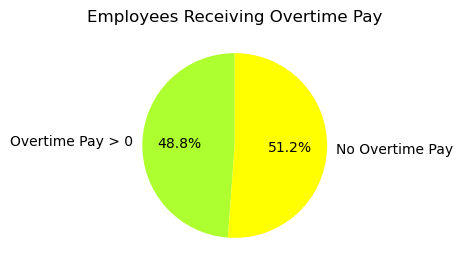

In [29]:
custom_colors= ['Greenyellow', 'yellow']
overtime_counts = [
    (data['OvertimePay'] > 0).sum(),
    (data['OvertimePay'] == 0).sum()]

# Plot
plt.figure(figsize=(5,3))
plt.pie(overtime_counts, labels=['Overtime Pay > 0',
                                 'No Overtime Pay'],
        startangle=90, colors=custom_colors, 
        autopct='%1.1f%%')
plt.title("Employees Receiving Overtime Pay")
plt.savefig("Employees Receiving Overtime Pay")
plt.show()

**Key Insights:**
  
The chart shows a clear year-wise trend in employee overtime pay, 48.8% employees getting overtime pay and 51.2% employees are not getting overtime pay working extra overs but still not getting overtime pay

### EDA 9. Total Salary Expenditure by Year


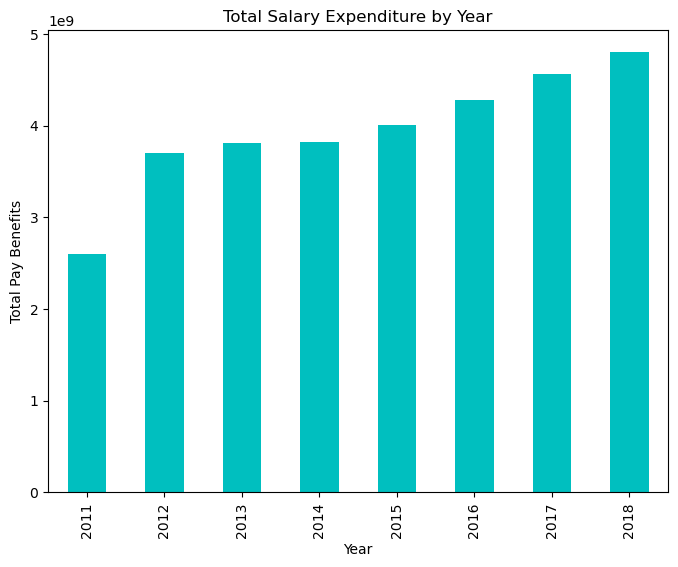

In [30]:
yearly_total = data.groupby('Year')['TotalPayBenefits'].sum()

# Plot
plt.figure(figsize=(8,6))
yearly_total.plot(kind='bar',color= "c")
plt.title("Total Salary Expenditure by Year")
plt.xlabel("Year")
plt.ylabel("Total Pay Benefits")
plt.savefig("Total Salary Expenditure by Year")
plt.show()

**Key Insights:**

Total salary expenditure increases steadily across years, reflecting growth in workforce cost and compensation levels. This trend suggests organizational expansion and salary revisions.

### EDA 10. Distribution of BasePay, OvertimePay, and OtherPay

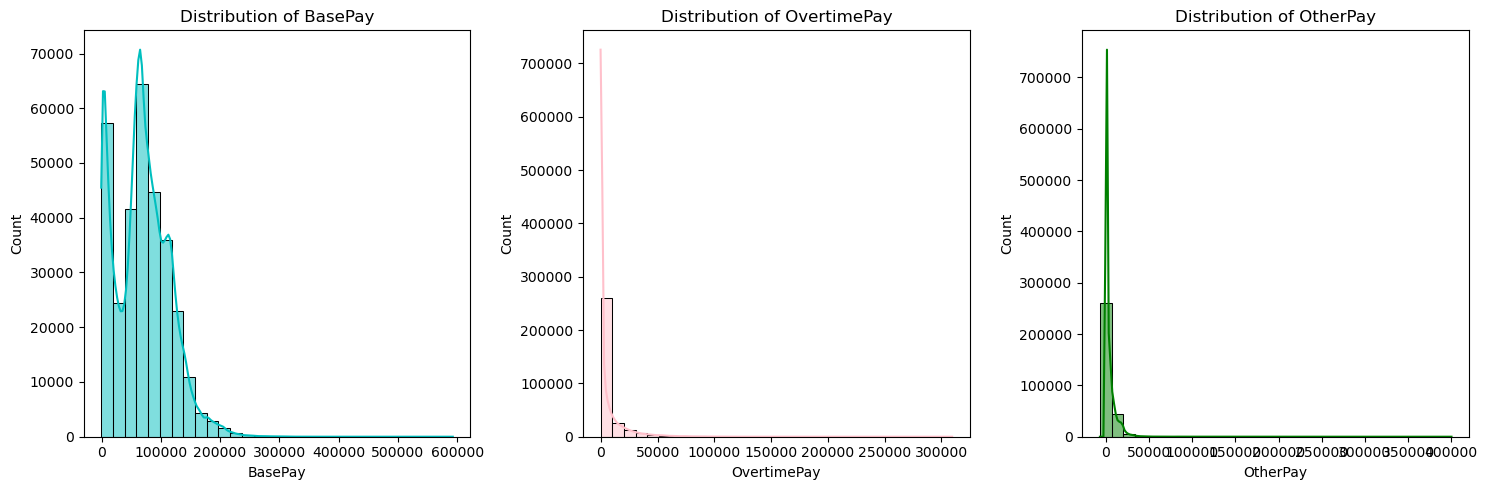

In [31]:
# Plot histograms for BasePay, OvertimePay, and OtherPay

# Plot

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(data['BasePay'], bins=30, kde=True, color='c')
plt.title('Distribution of BasePay')

plt.subplot(1,3,2)
sns.histplot(data['OvertimePay'], bins=30, kde=True, color='pink')
plt.title('Distribution of OvertimePay')

plt.subplot(1,3,3)
sns.histplot(data['OtherPay'], bins=30, kde=True, color='g')
plt.title('Distribution of OtherPay')
plt.tight_layout()
plt.savefig("Distribution of OtherPay")
plt.show()

**Key Insights:**

BasePay is the most consistent and dominant salary component.
OvertimePay and OtherPay are concentrated near lower values, with only a few employees receiving high additional pay.

### EDA 11. Percentage of Employees With vs Without Benefits


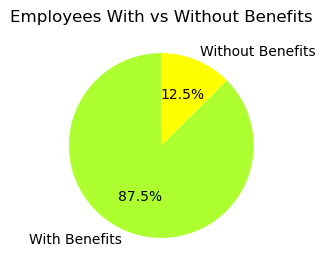

In [32]:
data['has_benefits'] = data['Benefits'].apply(lambda x: 'With Benefits' if x > 0 else 'Without Benefits')

benefit_counts = data['has_benefits'].value_counts()

# Plot

plt.figure(figsize=(5,3))
plt.pie(benefit_counts,
        labels=benefit_counts.index,
        autopct='%1.1f%%', colors =custom_colors,
        startangle=90)

plt.title("Employees With vs Without Benefits")
plt.savefig("Employees With vs Without Benefits")
plt.show()

**Key Insights:**

Most employees receive benefits as part of their compensation. Only a small percentage of employees do not receive benefits, making benefits a standard component of pay structure.

### EDA 12. Top 10 Job Titles by Benefits

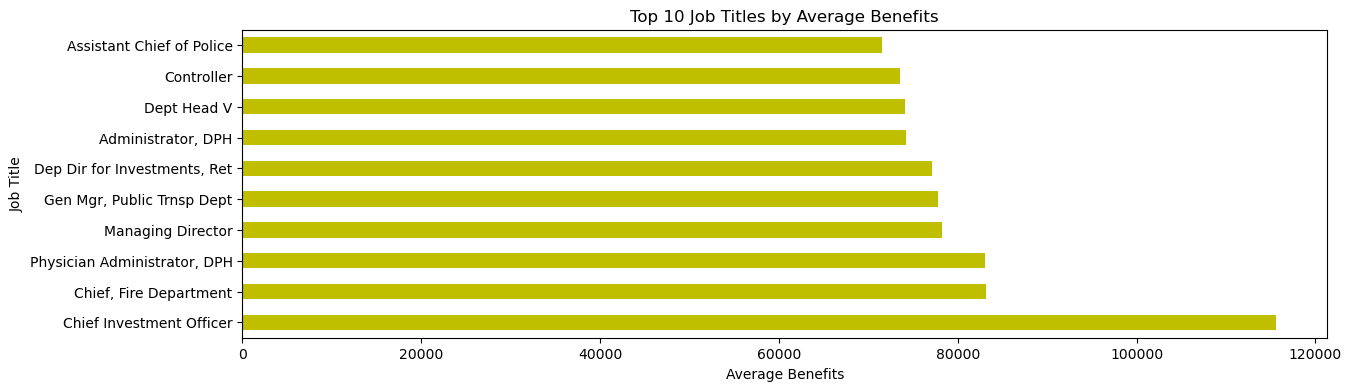

In [33]:
top_benefits_jobs = data.groupby('JobTitle')['Benefits'].mean().sort_values(ascending=False).head(10)

# Plot 

plt.figure(figsize=(14,4))
top_benefits_jobs.plot(kind='barh', color ="y")
plt.title("Top 10 Job Titles by Average Benefits")
plt.xlabel("Average Benefits")
plt.ylabel("Job Title")
plt.savefig("Top 10 Job Titles by Average Benefits")
plt.show()


**Key Insights:**

Senior administrative and leadership roles receive the highest benefits on average. This indicates that benefits increase with job level and responsibility.

# Step 5: Salary Prediction with Machine Learning
In this section, a machine learning approach is used to predict employee total compensation.
Based on the insights obtained from EDA and feature engineering, a regression model is built using key salary components such as BasePay, OvertimePay, OtherPay, and Benefits.
Linear Regression is chosen as the baseline model to understand the relationship between these features and TotalPayBenefits.


### Handling Categorical Variables

In [34]:
# Encoding JobTitle using one-hot encoding
data = pd.get_dummies(data, columns=['JobTitle'], drop_first=True)

 # Display new dataframe
data.head()

EmployeeName   BasePay  OvertimePay  OtherPay  Benefits  TotalPay  \
0     NATHANIEL FORD 167411.18         0.00 400184.25       NaN 567595.43   
1       GARY JIMENEZ 155966.02    245131.88 137811.38       NaN 538909.28   
2     ALBERT PARDINI 212739.13    106088.18  16452.60       NaN 335279.91   
3  CHRISTOPHER CHONG  77916.00     56120.71 198306.90       NaN 332343.61   
4    PATRICK GARDNER 134401.60      9737.00 182234.59       NaN 326373.19   

   TotalPayBenefits  Year      has_benefits  JobTitle_ACCOUNTANT  \
0         567595.43  2011  Without Benefits                False   
1         538909.28  2011  Without Benefits                False   
2         335279.91  2011  Without Benefits                False   
3         332343.61  2011  Without Benefits                False   
4         326373.19  2011  Without Benefits                False   

   JobTitle_ACCOUNTANT INTERN  JobTitle_ACPO,JuvP, Juv Prob (SFERS)  \
0                       False                                 False   
1                       False                                 False   
2                       False                                 False   
3                       False                                 False   
4                       False                                 False   

   JobTitle_ACUPUNCTURIST  JobTitle_ADMINISTRATIVE ANALYST  \
0                   False                            False   
1                   False                            False   
2                   False                            False   
3                   False                            False   
4                   False                            False   

   JobTitle_ADMINISTRATIVE ANALYST II  JobTitle_ADMINISTRATIVE ANALYST III  \
0                               False                                False   
1                               False                                False   
2                               False                                False   
3                               False                                False   
4                               False                                False   

   JobTitle_ADMINISTRATIVE ENGINEER  JobTitle_ADMINISTRATIVE SERVICES MANAGER  \
0                             False                                     False   
1                             False                                     False   
2                             False                                     False   
3                             False                                     False   
4                             False                                     False   

   JobTitle_ADMINISTRATOR, SFGH MEDICAL CENTER  \
0                                        False   
1                                        False   
2                                        False   
3                                        False   
4                                        False   

   JobTitle_AFFIRMATIVE ACTION SPECIALIST  JobTitle_AGRICULTURAL INSPECTOR  \
0                                   False                            False   
1                                   False                            False   
2                                   False                            False   
3                                   False                            False   
4                                   False                            False   

   JobTitle_AIRPORT ASSISTANT DEPUTY DIRECTOR, BUSINESS ADMINI  \
0                                              False             
1                                              False             
2                                              False             
3                                              False             
4                                              False             

   JobTitle_AIRPORT ASSISTANT DEPUTY DIRECTOR, OPERATIONS  \
0                                              False        
1                                              False        
2                             

### Step 1. Feature and Target Selection

In [35]:
# Select input features
X = data[["BasePay", "OvertimePay", "OtherPay", "Benefits"]]

# Select targe variable
Y = data["TotalPayBenefits"]

# Check shapes
X.shape, Y.shape

((312882, 4), (312882,))

In this step, input features that influence employee salary are selected as independent variables (X), and TotalPayBenefits is chosen as the target variable (y). 



### Step 2. Train–Test Split

In [36]:
from sklearn.model_selection import train_test_split

# Split data into trainiing and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size= 0.2, random_state = 42)

# Check split sizes
X_train.shape, X_test.shape

((250305, 4), (62577, 4))

The dataset is divided into training and testing sets to evaluate the model on unseen data.
80% of the data is used for training and 20% is reserved for testing to ensure fair performance evaluation.

### Step 3. Model Training

In [37]:
from sklearn.impute import SimpleImputer

In [38]:
imputer = SimpleImputer(strategy='mean')

In [39]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test) 

In [40]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


A Linear Regression model is trained using the training dataset.
The model learns the relationship between salary components and total compensation.

### Step 4. Model Prediction

In [41]:
# Predict values using the trained model
Y_pred = model.predict(X_test)

# Display first few predictions
Y_pred[:5]

array([ 95669.33487436, 100341.34249036,  -3229.14061829,    930.27192077,
       114996.04670906])

In this step, the trained model is used to predict TotalPayBenefits for the test dataset.
These predicted values are later compared with actual values to evaluate model performance.

### Step 5. Model Evaluation

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

mae, mse, rmse, r2

(5308.210653423338,
 72477144.1432835,
 np.float64(8513.350935048049),
 0.9835996534796263)

- Model performance is evaluated using regression metrics.
- Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) measure prediction error, while R² score shows how well the model explains the variance in total compensation.
- A higher R² value indicates better model performance.

**Final Insights:**
BasePay is the primary contributor to employee compensation.
OvertimePay and Benefits vary significantly across job roles.
Senior and leadership roles receive higher salaries and benefits.



# Step 6: Generate Report

Summary The Salaries of Employees dataset was analyzed to identify key trends and insights. The data cleaning process involved handling missing values, correcting data types, and removing duplicates. The project successfully analyzed employee salary data using EDA and machine learning. Important salary patterns were identified through visualization and analysis. A salary prediction model was built and evaluated with satisfactory performance. The project demonstrates the practical use of data analytics for compensation analysis.